In [1]:
import numpy as np
import matplotlib.pyplot as plt

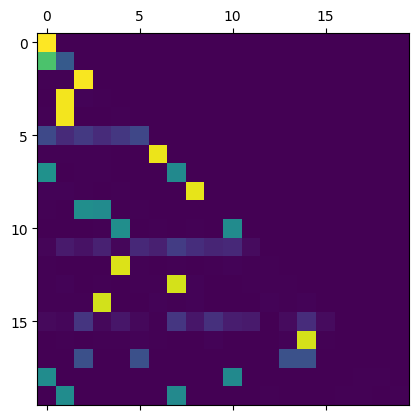

In [36]:
# start with a random square matrix, make it LT, normalize rows
n: int = 20
A: np.ndarray = np.random.rand(n, n)
# add salt and pepper noise
A[A < 0.9] = 0
A = A + np.random.rand(n, n) * 0.01
A = np.tril(A)
A = A / np.sum(A, axis=1)[:, np.newaxis]

plt.matshow(A)

In [53]:
def transition_tensor(A: np.ndarray, K: int) -> np.ndarray:
    """
    Compute the 3D array `X` of shape `(n, n, K+1)` such that `X[i, j, k]` = Probability of being in state j at step k if we start in state i at step 0.

    # Parameters
    - `A: np.ndarray`
        An n x n transition matrix (row-stochastic for a standard Markov chain).
    - `K: int`
        The maximum number of steps for which to compute transition probabilities.

    # Returns
    `X: np.ndarray`
	A 3D NumPy array of shape (n, n, K+1). 
	- X[:, :, 0] is the identity matrix (k=0).
	- X[:, :, k] is A^k for k >= 1.
    """
    n: int = A.shape[0]
    # Allocate output array
    X = np.zeros((n, n, K + 1), dtype=A.dtype)
    
    # Step 0: identity distribution
    X[:, :, 0] = np.eye(n, dtype=A.dtype)
    
    # Compute powers of A iteratively
    for k in range(1, K + 1):
        X[:, :, k] = X[:, :, k - 1] @ A
    
    return X

T = transition_tensor(A, 1000)
T_resample = np.concatenate([
    T[:, :, :10],
    T[:, :, np.logspace(1, 3, 20, base=10, dtype=int)],
],
axis=-1,
)
T_resample.shape

(20, 20, 30)

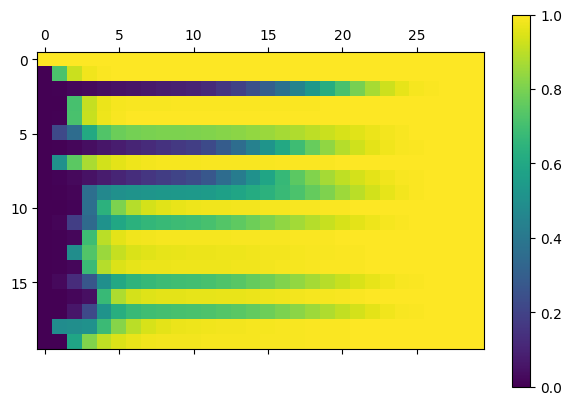

In [54]:
plt.matshow(T_resample[:, 0, :])
plt.colorbar()
plt.show()

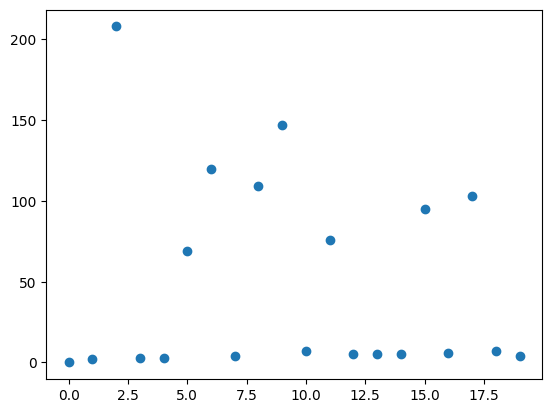

f:\projects\attention-motifs\.venv\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
f:\projects\attention-motifs\.venv\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


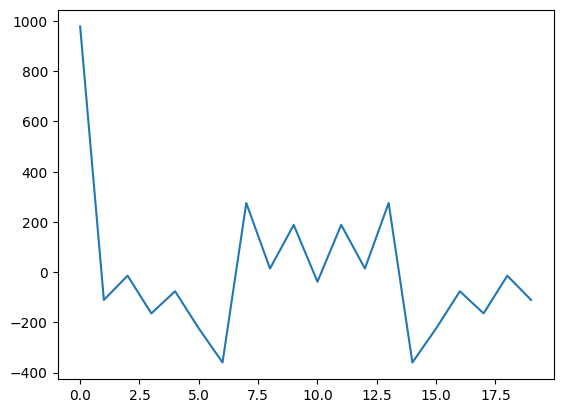

In [59]:
ttl = np.argmax(T[:, 0, :] > 0.9, axis=1)
ttl.shape
plt.plot(ttl, 'o')
plt.show()

plt.plot(np.fft.fft(ttl))
plt.show()

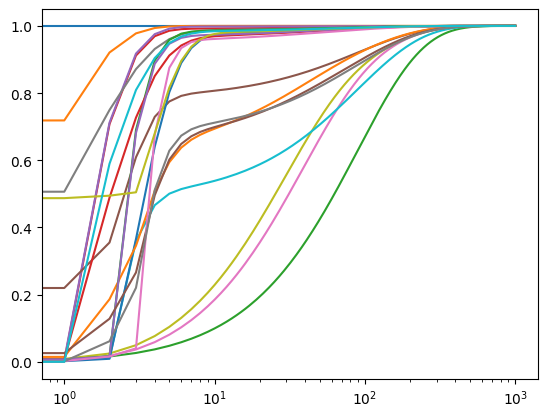

In [43]:
for i in range(n):
	plt.plot(T[i, 0, :], label=f"i={i}")
# plt.legend()
plt.xscale("log")
# plt.yscale("log")
plt.show()

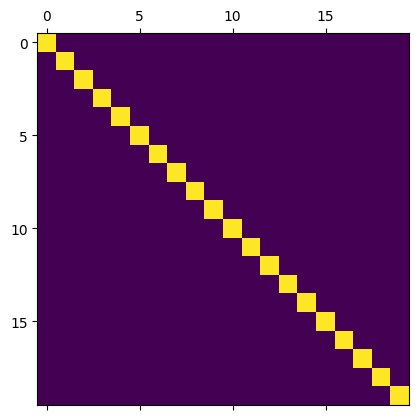

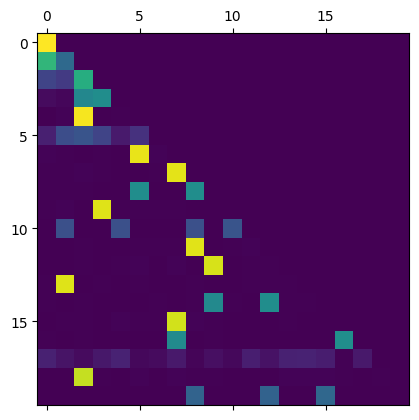

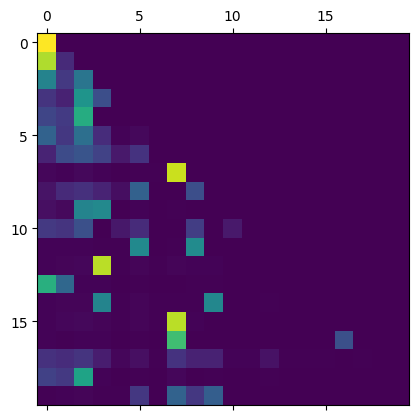

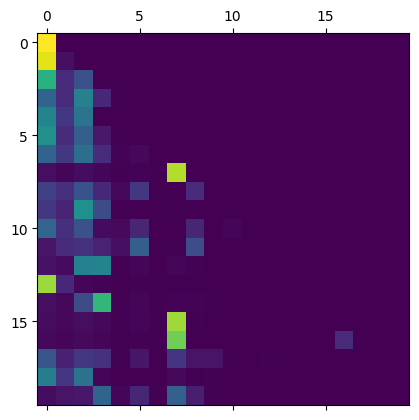

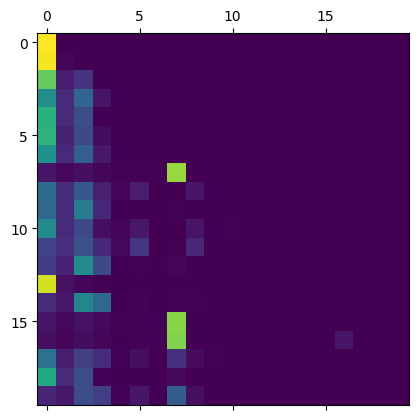

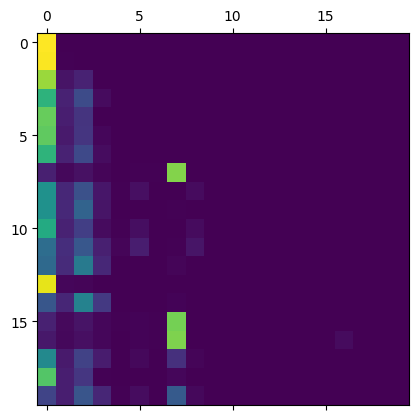

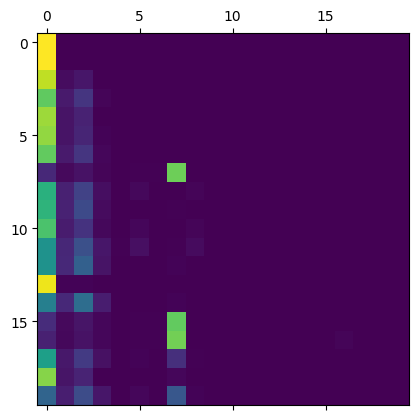

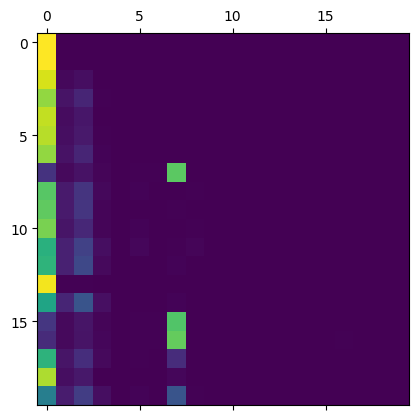

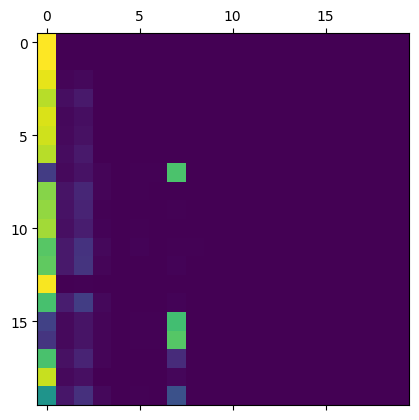

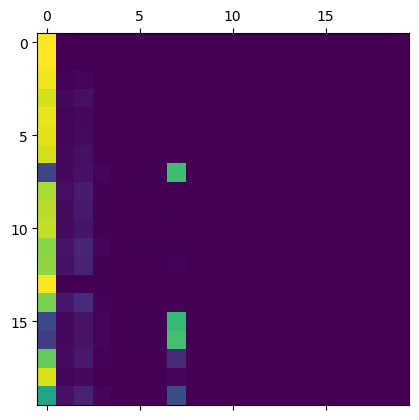

In [20]:
for i in range(10):
	plt.matshow(T[:, :, i])
	plt.show()